In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import normalize
import hdbscan
import umap

In [6]:
# reading in the words.txt
with open('words.txt', 'r') as f:
    words = f.read().splitlines()

# convert to numpy array
words = np.array(words)
words

array(['birds', 'fuel', 'hammer', 'macabre', 'pray', 'unruly', 'blood',
       'identify', 'opposite', 'erect', 'battle', 'public', 'concern',
       'develop', 'placid', 'surround', 'cart', 'burly', 'empty',
       'bite-sized', 'imaginary', 'zippy', 'tour', 'plate', 'terrible',
       'regular', 'volleyball', 'chemical', 'flaky', 'sophisticated',
       'innate', 'wobble', 'pushy', 'superb', 'truck', 'gainful', 'false',
       'reaction', 'jam', 'tank', 'telling', 'rhetorical', 'encourage',
       'peck', 'meddle', 'sudden', 'offbeat', 'paltry', 'grumpy',
       'entertaining', 'paste', 'cheerful', 'sail', 'exist', 'experience',
       'nod', 'pretty', 'delight', 'wrench', 'neck', 'sable',
       'scientific', 'creator', 'chess', 'general', 'discover', 'selfish',
       'foregoing', 'neat', 'stiff', 'waiting', 'children', 'sort',
       'horse', 'kick', 'rock', 'type', 'hissing', 'harass', 'announce',
       'boat', 'rich', 'birth', 'young', 'vest', 'lush', 'hang', 'letter',
       '

In [7]:
# encode vectors
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(words, show_progress_bar=True)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

C:\Users\jessh\projects\CS4100-Project\venv\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\jessh\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/10 [00:00<?, ?it/s]

In [8]:
# normalize the embeddings
embeddings = normalize(embeddings)

In [9]:
# run HDBSCAN
clusterer = hdbscan.HDBSCAN(min_cluster_size=5, min_samples=1, metric='euclidean')
cluster_labels = clusterer.fit_predict(embeddings)

In [10]:
# construct the clusters
from collections import defaultdict

clusters = defaultdict(list)
for word, label in zip(words, cluster_labels):
    # account for noise
    if label != -1:
        clusters[label].append(word)




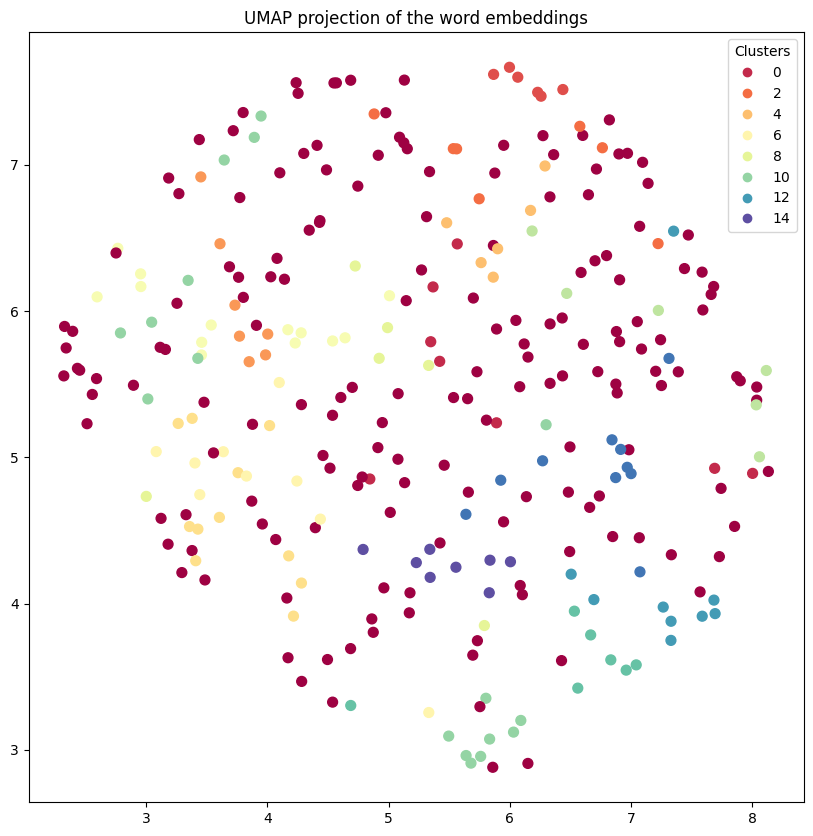

In [11]:
# visualize with umap
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='euclidean')
embedding_2d = reducer.fit_transform(embeddings)
plt.figure(figsize=(10, 10))
scatter = plt.scatter(embedding_2d[:, 0], embedding_2d[:, 1], c=cluster_labels, cmap='Spectral', s=50)
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.title('UMAP projection of the word embeddings')
plt.show()

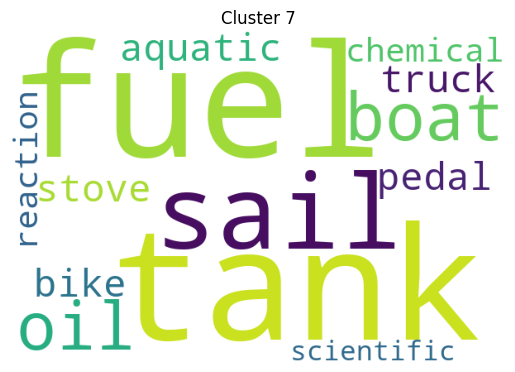

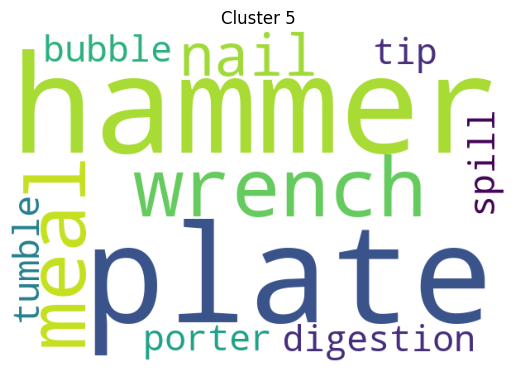

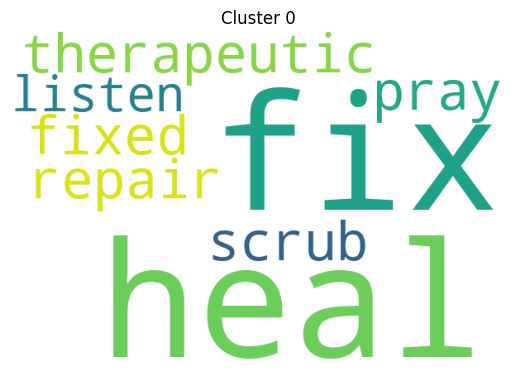

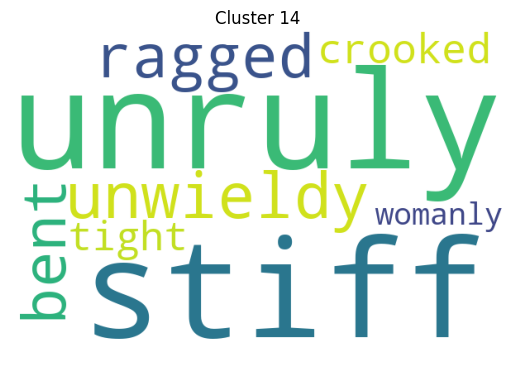

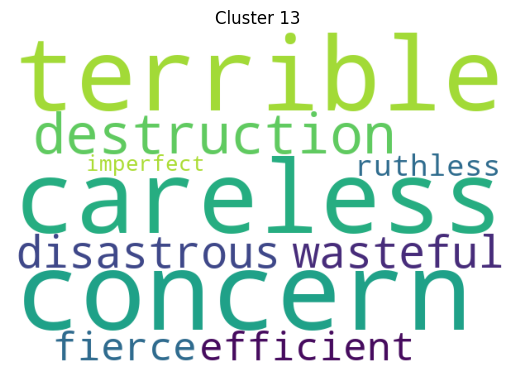

In [16]:
from wordcloud import WordCloud

# visualize with word clouds
probs = clusterer.probabilities_

# for thr first 5 clusters
for cluster_id in list(clusters.keys())[:5]:
    freqs = {}

    for i, (word, label) in enumerate(zip(words, cluster_labels)):
        if label == cluster_id:
            # weighting the clusters
            freqs[word] = probs[i]

    wc = WordCloud(
        width=600,
        height=400,
        background_color="white"
    ).generate_from_frequencies(freqs)

    plt.figure()
    plt.imshow(wc)
    plt.axis("off")
    plt.title(f"Cluster {cluster_id}")
    plt.show()